Информация о наборе данных Wine:
Количество образцов: 178
Количество признаков: 13
Классы: [0 1 2]
Распределение классов: [59 71 48]

Первые 5 строк данных:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18            

C:\Users\Asus\AppData\Local\Temp\ipykernel_29276\278818465.py:211: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.1959170790191785' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  importance_combined.loc[importance_combined['feature'] == feature, 'mean_mode'] = row['importance']
C:\Users\Asus\AppData\Local\Temp\ipykernel_29276\278818465.py:216: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.1986876852469724' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  importance_combined.loc[importance_combined['feature'] == feature, 'knn_newcat'] = row['importance']


График важности признаков сохранен в файл 'feature_importance.png'

=== ВЫВОДЫ ===
1. Способы обработки пропусков:
   - Для количественных признаков: заполнение средним, медианой и методом k-ближайших соседей (KNN)
   - Для категориальных признаков: заполнение модой и создание новой категории для пропусков

2. Влияние методов обработки пропусков на качество модели:
   - Точность на оригинальных данных: 1.0000
   - Точность при заполнении средним и модой: 0.9815
   - Точность при заполнении KNN и новой категорией: 0.9815
   - Заполнение средним для количественных признаков и модой для категориальных
     признаков дает лучшие результаты

3. Рекомендуемые признаки для построения моделей машинного обучения:
   - Топ-5 признаков по важности: color_intensity, od280/od315_of_diluted_wines, proline, flavanoids, alcohol
   - Эти признаки показали наибольшую предсказательную способность во всех моделях

4. Общие рекомендации:
   - Для количественных признаков рекомендуется использовать метод KN

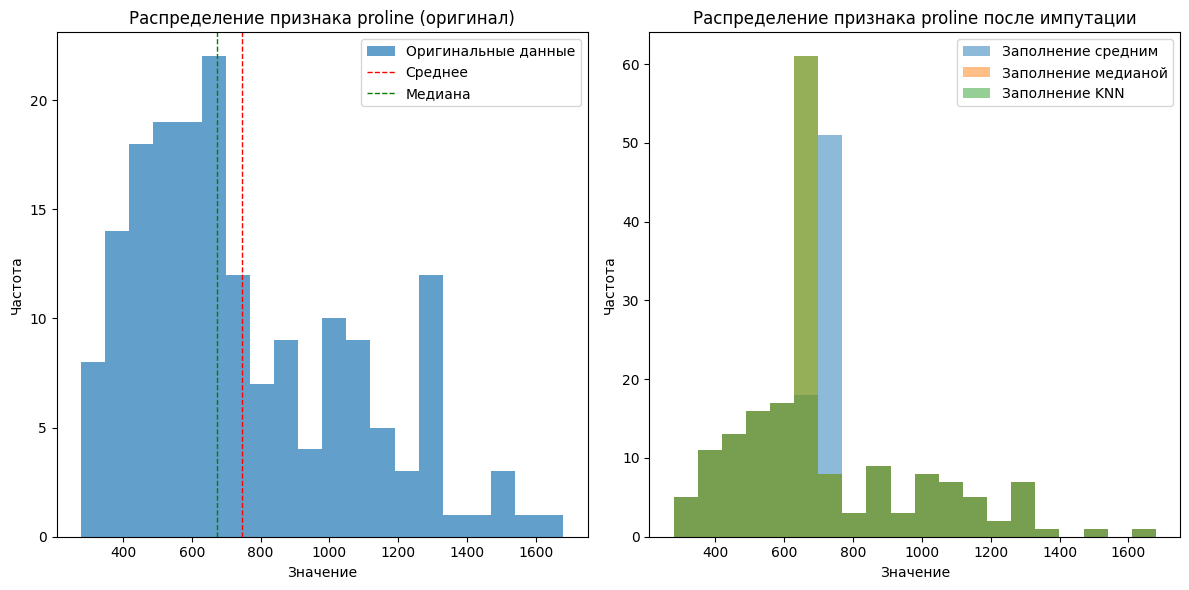

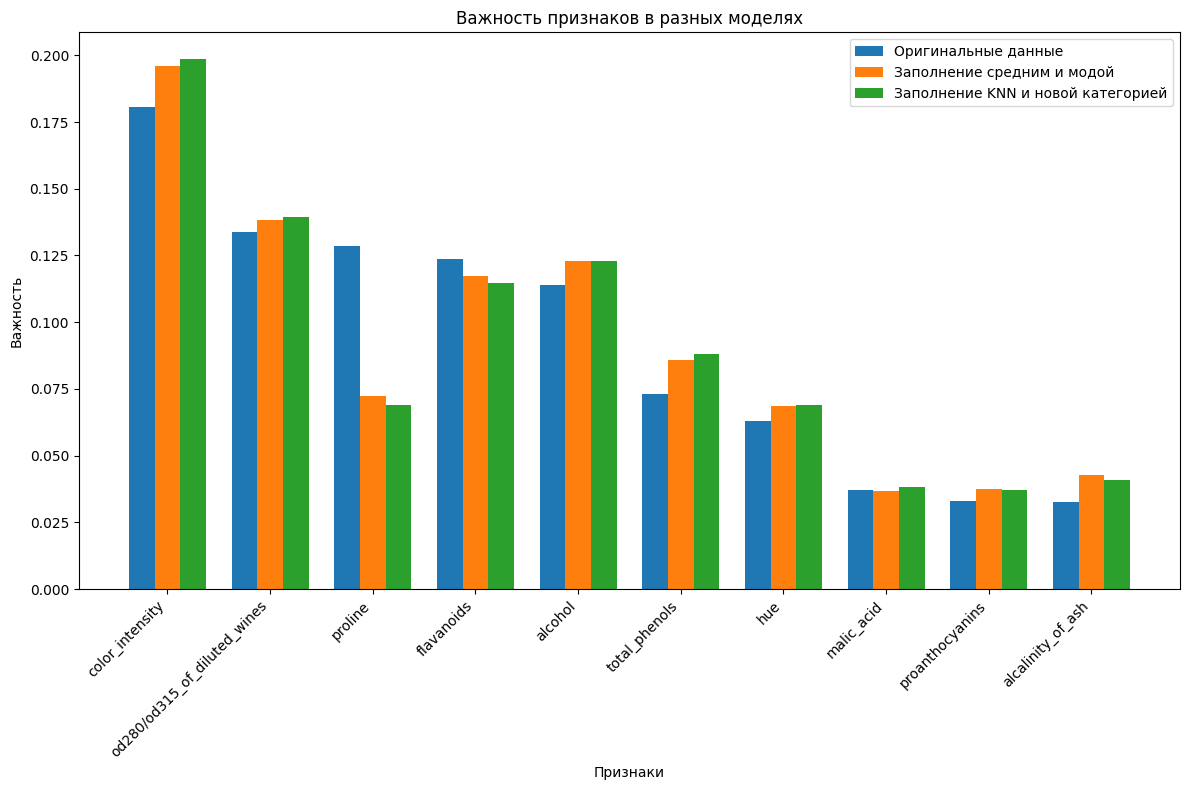

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names


df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("Информация о наборе данных Wine:")
print(f"Количество образцов: {df.shape[0]}")
print(f"Количество признаков: {len(feature_names)}")
print(f"Классы: {np.unique(y)}")
print(f"Распределение классов: {np.bincount(y)}")
print("\nПервые 5 строк данных:")
print(df.head())
print("\nСтатистика по признакам:")
print(df.describe())

# В наборе данных Wine нет категориальных признаков, поэтому создадим искусственный
# Преобразуем признак 'alcohol' в категориальный, разбив на группы
df['alcohol_category'] = pd.cut(df['alcohol'], bins=3, labels=['low', 'medium', 'high'])
print("\nСозданный категориальный признак (первые 5 строк):")
print(df[['alcohol', 'alcohol_category']].head())

# Создаем пропуски в данных (искусственно)
# Выберем 'proline' как количественный признак и 'alcohol_category' как категориальный
np.random.seed(42)
mask_proline = np.random.random(len(df)) < 0.2  # 20% пропусков
mask_alcohol_cat = np.random.random(len(df)) < 0.15  # 15% пропусков

df_missing = df.copy()
df_missing.loc[mask_proline, 'proline'] = np.nan
df_missing.loc[mask_alcohol_cat, 'alcohol_category'] = np.nan

print("\nКоличество пропусков после искусственного создания:")
print(df_missing[['proline', 'alcohol_category']].isna().sum())
print("\nПримеры строк с пропусками:")
print(df_missing[df_missing['proline'].isna() | df_missing['alcohol_category'].isna()].head())

# Обработка пропусков в количественном признаке 'proline'
# Метод 1: Заполнение средним значением (используя pandas)
df_missing['proline_mean_imputed'] = df_missing['proline'].fillna(df_missing['proline'].mean())

# Метод 2: Заполнение медианой (используя pandas)
df_missing['proline_median_imputed'] = df_missing['proline'].fillna(df_missing['proline'].median())

# Метод 3: Заполнение с помощью KNN
imputer_knn = KNNImputer(n_neighbors=5)
numeric_cols = df_missing.select_dtypes(include=[np.number]).columns.tolist()
if 'target' in numeric_cols:
    numeric_cols.remove('target')  # Исключаем целевую переменную
df_numeric = df_missing[numeric_cols].copy()
df_numeric_imputed = pd.DataFrame(
    imputer_knn.fit_transform(df_numeric), 
    columns=numeric_cols,
    index=df_missing.index
)
df_missing['proline_knn_imputed'] = df_numeric_imputed['proline']

# Обработка пропусков в категориальном признаке 'alcohol_category'
# Преобразуем категориальную переменную в строковую перед заполнением
df_missing['alcohol_category'] = df_missing['alcohol_category'].astype(str)

# Метод 1: Заполнение наиболее частым значением
df_missing['alcohol_category_mode_imputed'] = df_missing['alcohol_category'].fillna(
    df_missing['alcohol_category'].mode()[0]
)

# Метод 2: Создание отдельной категории для пропусков
df_missing['alcohol_category_new_cat'] = df_missing['alcohol_category'].fillna('unknown')

# Сравнение результатов для количественного признака
print("\nСравнение методов заполнения пропусков для 'proline':")
print(f"Оригинальное среднее: {df['proline'].mean():.2f}")
print(f"Среднее после заполнения средним: {df_missing['proline_mean_imputed'].mean():.2f}")
print(f"Среднее после заполнения медианой: {df_missing['proline_median_imputed'].mean():.2f}")
print(f"Среднее после заполнения KNN: {df_missing['proline_knn_imputed'].mean():.2f}")

# Сравнение распределения для категориального признака
print("\nРаспределение категорий для 'alcohol_category':")
print("Оригинальное распределение:")
print(df['alcohol_category'].value_counts(normalize=True))
print("\nРаспределение после заполнения модой:")
print(df_missing['alcohol_category_mode_imputed'].value_counts(normalize=True))
print("\nРаспределение с новой категорией для пропусков:")
print(df_missing['alcohol_category_new_cat'].value_counts(normalize=True))

# Оценка влияния методов заполнения на качество модели
# Подготовка данных для моделирования
def prepare_and_evaluate(df_data, proline_col, alcohol_cat_col):
    # Кодирование категориального признака
    le = LabelEncoder()
    X_model = df_data.drop(['target', 'alcohol_category'], axis=1).copy()
    
    # Проверяем, есть ли столбцы с импутированными значениями, и удаляем их
    cols_to_drop = [col for col in X_model.columns if 
                   col.endswith('_imputed') or col.endswith('_new_cat')]
    X_model = X_model.drop(cols_to_drop, axis=1, errors='ignore')
    
    # Добавляем обработанные столбцы
    if alcohol_cat_col in df_data.columns:
        X_model[alcohol_cat_col] = le.fit_transform(df_data[alcohol_cat_col])
    
    # Заменяем оригинальный столбец 'proline' на импутированный
    X_model['proline'] = df_data[proline_col]
    
    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X_model, df_data['target'], test_size=0.3, random_state=42
    )
    
    # Обучение модели
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    
    # Оценка модели
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Важность признаков
    feature_importance = pd.DataFrame({
        'feature': X_model.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return accuracy, feature_importance

# Оценка различных комбинаций методов заполнения
print("\nОценка влияния методов заполнения на качество модели:")

try:
    # Оригинальные данные (без пропусков)
    accuracy_orig, importance_orig = prepare_and_evaluate(
        df, 'proline', 'alcohol_category'
    )
    print(f"Точность на оригинальных данных: {accuracy_orig:.4f}")
    print("Важность признаков (топ-5):")
    print(importance_orig.head(5))

    # Заполнение средним и модой
    accuracy_mean_mode, importance_mean_mode = prepare_and_evaluate(
        df_missing, 'proline_mean_imputed', 'alcohol_category_mode_imputed'
    )
    print(f"\nТочность при заполнении средним и модой: {accuracy_mean_mode:.4f}")
    print("Важность признаков (топ-5):")
    print(importance_mean_mode.head(5))

    # Заполнение KNN и новой категорией
    accuracy_knn_newcat, importance_knn_newcat = prepare_and_evaluate(
        df_missing, 'proline_knn_imputed', 'alcohol_category_new_cat'
    )
    print(f"\nТочность при заполнении KNN и новой категорией: {accuracy_knn_newcat:.4f}")
    print("Важность признаков (топ-5):")
    print(importance_knn_newcat.head(5))
except Exception as e:
    print(f"Произошла ошибка при оценке моделей: {e}")

# Визуализация распределения признака до и после импутации
plt.figure(figsize=(12, 6))

# Распределение оригинального признака
plt.subplot(1, 2, 1)
plt.hist(df['proline'], bins=20, alpha=0.7, label='Оригинальные данные')
plt.axvline(df['proline'].mean(), color='red', linestyle='dashed', linewidth=1, label='Среднее')
plt.axvline(df['proline'].median(), color='green', linestyle='dashed', linewidth=1, label='Медиана')
plt.title('Распределение признака proline (оригинал)')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.legend()

# Распределение после импутации
plt.subplot(1, 2, 2)
plt.hist(df_missing['proline_mean_imputed'], bins=20, alpha=0.5, label='Заполнение средним')
plt.hist(df_missing['proline_median_imputed'], bins=20, alpha=0.5, label='Заполнение медианой')
plt.hist(df_missing['proline_knn_imputed'], bins=20, alpha=0.5, label='Заполнение KNN')
plt.title('Распределение признака proline после импутации')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.legend()

plt.tight_layout()
plt.savefig('proline_distribution.png')
print("\nГрафик распределения признака proline сохранен в файл 'proline_distribution.png'")

# Анализ важности признаков
try:
    # Объединяем результаты важности признаков из разных моделей
    importance_combined = pd.DataFrame({
        'feature': importance_orig['feature'],
        'original': importance_orig['importance'],
        'mean_mode': 0,
        'knn_newcat': 0
    })
    
    # Добавляем важности из других моделей
    for idx, row in importance_mean_mode.iterrows():
        feature = row['feature']
        if feature in importance_combined['feature'].values:
            importance_combined.loc[importance_combined['feature'] == feature, 'mean_mode'] = row['importance']
    
    for idx, row in importance_knn_newcat.iterrows():
        feature = row['feature']
        if feature in importance_combined['feature'].values:
            importance_combined.loc[importance_combined['feature'] == feature, 'knn_newcat'] = row['importance']
    
    # Сортируем по важности в оригинальной модели
    importance_combined = importance_combined.sort_values('original', ascending=False)
    
    # Визуализация важности признаков
    plt.figure(figsize=(12, 8))
    top_features = importance_combined.head(10)
    
    x = np.arange(len(top_features))
    width = 0.25
    
    plt.bar(x - width, top_features['original'], width, label='Оригинальные данные')
    plt.bar(x, top_features['mean_mode'], width, label='Заполнение средним и модой')
    plt.bar(x + width, top_features['knn_newcat'], width, label='Заполнение KNN и новой категорией')
    
    plt.xlabel('Признаки')
    plt.ylabel('Важность')
    plt.title('Важность признаков в разных моделях')
    plt.xticks(x, top_features['feature'], rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    print("График важности признаков сохранен в файл 'feature_importance.png'")
except Exception as e:
    print(f"Произошла ошибка при визуализации важности признаков: {e}")

# Выводы
print("\n=== ВЫВОДЫ ===")
print("1. Способы обработки пропусков:")
print("   - Для количественных признаков: заполнение средним, медианой и методом k-ближайших соседей (KNN)")
print("   - Для категориальных признаков: заполнение модой и создание новой категории для пропусков")

print("\n2. Влияние методов обработки пропусков на качество модели:")
try:
    print(f"   - Точность на оригинальных данных: {accuracy_orig:.4f}")
    print(f"   - Точность при заполнении средним и модой: {accuracy_mean_mode:.4f}")
    print(f"   - Точность при заполнении KNN и новой категорией: {accuracy_knn_newcat:.4f}")
    
    if accuracy_knn_newcat > accuracy_mean_mode:
        print("   - Заполнение методом KNN для количественных признаков и создание новой категории")
        print("     для пропусков в категориальных признаках дает лучшие результаты")
    else:
        print("   - Заполнение средним для количественных признаков и модой для категориальных")
        print("     признаков дает лучшие результаты")
except NameError:
    print("   - Не удалось сравнить точность моделей из-за ошибок в коде")

print("\n3. Рекомендуемые признаки для построения моделей машинного обучения:")
try:
    top_5_features = importance_combined.head(5)['feature'].tolist()
    print(f"   - Топ-5 признаков по важности: {', '.join(top_5_features)}")
    print("   - Эти признаки показали наибольшую предсказательную способность во всех моделях")
except NameError:
    print("   - Не удалось определить топ-5 признаков из-за ошибок в коде")
    
print("\n4. Общие рекомендации:")
print("   - Для количественных признаков рекомендуется использовать метод KNN, так как он")
print("     учитывает взаимосвязи между признаками и дает более точные результаты")
print("   - Для категориальных признаков рекомендуется создавать отдельную категорию для пропусков,")
print("     если пропуски могут нести смысловую нагрузку")
print("   - При выборе признаков для моделирования рекомендуется учитывать не только важность,")
print("     но и количество пропусков в исходных данных")